# MWE: a flared disk and two planets, PDS 70 style

Blakely et al. (2024, arXiv:2404.13032) detected the protoplanets PDS 70 b and c in JWST AMI data by fitting the star, both planets and the outer disk together, since all three contribute to every visibility. The disk is a geometrical scattered-light model: a skewed Gaussian ring on a flared surface, inclined, and brightest on its near side where light is forward scattered. drpangloss has this as `FlaredDiskPowerLaw` (with `FlaredDiskHG` and `FlaredDiskGaussian` for the paper's other two phase functions), an ordinary component that goes in a `System` next to `PointSource` star and planets.

This notebook simulates AMI data of the paper's best-fitting model and fits all fifteen parameters back. You should come away knowing how to build the scene, fit it, and how well each parameter is recovered when the model is right, as a baseline for the real data in `mwe_pds70_data.ipynb`.

The first cell builds the paper's model, with planets b and c at their published separations, position angles and contrasts, and simulates AMIGO-like DISCO data of it at 4.8 µm (F480M) on a uv lattice rotated like the PDS 70 observation, with errors similar to the real product's.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from drpangloss.coverage import ami_grid_record
from drpangloss.fitting import fit
from drpangloss.imaging import beam
from drpangloss.inference import laplace_cov
from drpangloss.limits import delta_mag_to_flux
from drpangloss.models import FlaredDiskPowerLaw, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map


def planet(sep, pa, delta_mag):
    """A point-source planet at separation (mas) and PA (deg, N to E)."""
    th = jnp.radians(pa)
    return PointSource(
        flux=delta_mag_to_flux(delta_mag),
        dra=sep * jnp.sin(th),
        ddec=sep * jnp.cos(th),
    )


# The power-law model of Blakely et al. (2024), Tables 1-2. The aspect
# ratio is their H_100 = 14.7 au converted to z/rho at r0 (r0 = 52 au at
# 113.43 pc), and symmetric = A_s/A_a = exp(-8.2 + 5.14).
paper = System(
    star=PointSource(),
    b=planet(150.5, 131.2, 5.84),
    c=planet(218.4, 270.0, 6.48),
    disk=FlaredDiskPowerLaw(
        n=6.6,
        radius=460.0,
        fwhm=220.0,
        inc=52.3,
        pa=160.4,
        skew=2.7,
        aspect=0.125,
        symmetric=0.05,
        flux=0.05,
        npix=96,
        pixel_scale_mas=20.0,
    ),
)

data = OIData(
    ami_grid_record(wavelength_m=4.8e-6, rotation_deg=31.7, sigma=1e-4)
).with_model(paper, key=jax.random.PRNGKey(0))
print(
    f"{data.u.size} uv samples, {data.vis.size} DISCO modes; "
    f"disk/star flux {float(paper.disk.flux):.2f}, "
    f"b/star {float(paper.b.flux):.4f}, c/star {float(paper.c.flux):.4f}"
)

W1001 15:02:29.931689 10657777 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


412 uv samples, 588 DISCO modes; disk/star flux 0.05, b/star 0.0046, c/star 0.0026


## The scene

The rendered scene shows the disk's forward-scattering peak on the near side, to the south-west of the star (East is left), with b to the south-east and c to the west, just inside the ring. The colour scale saturates at the brightest 0.5% of pixels so that the disk and planets are visible next to the star, and white circles mark the planets. The disk's visibilities are the exact Fourier transform of its brightness on a 96 × 96 grid of 20 mas pixels, which covers the whole ring.

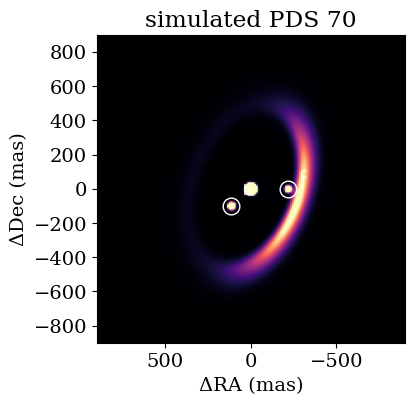

In [2]:
ax = plot_model(
    paper, fov_mas=1800.0, npix=180, saturate=0.995, title="simulated PDS 70"
)
for name in ("b", "c"):
    p = paper.components[name]
    ax.plot(p.dra, p.ddec, "o", mfc="none", mec="w", ms=12)
    ax.annotate(name, (p.dra, p.ddec), xytext=(8, 8),
                textcoords="offset points", color="w")
plt.show()

## Fitting the planets and the disk together

Every parameter is addressed by its path through the component names, so the priors double as the list of free parameters: the two planets' positions and fluxes, and the disk's flux, radius, width, inclination, position angle, inner-edge skew, surface height, phase-function power and symmetric part. The flaring index stays at 1.25, where the paper's prior pinned it. The paper's over-resolved flux $I_o$ (a `Resolved` component) is left out: AMIGO projects the overall visibility amplitude out of the DISCO modes, so it cannot be measured. The fit starts away from the truth for every parameter.

In [3]:
# Priors after Blakely et al. (2024): boxes for the planets, and Gaussian
# priors on the disk's orientation and surface height from earlier work.
priors = {
    "b.dra": dist.Uniform(0.0, 250.0),
    "b.ddec": dist.Uniform(-250.0, 0.0),
    "b.flux": dist.Uniform(0.0, 0.03),
    "c.dra": dist.Uniform(-300.0, -100.0),
    "c.ddec": dist.Uniform(-100.0, 100.0),
    "c.flux": dist.Uniform(0.0, 0.03),
    "disk.flux": dist.Uniform(0.0, 0.3),
    "disk.radius": dist.Uniform(350.0, 650.0),
    "disk.fwhm": dist.Uniform(30.0, 1000.0),
    "disk.inc": dist.Normal(51.7, 1.0),
    "disk.pa": dist.Normal(160.4, 1.0),
    "disk.skew": dist.Uniform(0.0, 10.0),
    "disk.aspect": dist.TruncatedNormal(0.11, 0.04, low=0.0),
    "disk.n": dist.Uniform(0.0, 100.0),
    "disk.symmetric": dist.Uniform(0.0, 1.0),
}
start = paper.set(
    list(priors),
    [100.0, -90.0, 0.003, -200.0, 10.0, 0.004,
     0.03, 500.0, 300.0, 51.7, 160.4, 1.0, 0.11, 4.0, 0.1],
)
result = fit(start, priors, data)
info = result.info
print(
    f"{info['method']} converged in {info['steps']} steps, "
    f"chi2/N = {info['chi2_red']:.3f} over {info['ndata'][0]} modes"
)

lbfgs converged in 112 steps, chi2/N = 0.981 over 588 modes


## How well each parameter is recovered

The uncertainties are the Laplace approximation, the inverse Hessian of the likelihood at the fit (without the priors). The planets' positions are recovered to a couple of milliarcseconds and their fluxes to 2–4%, and the disk's geometry is recovered too, with the skew of its inner edge the least well constrained, as in the paper.

In [4]:
values = jnp.array([result.values[p] for p in priors])
sigma = jnp.sqrt(jnp.diag(laplace_cov(values, list(priors), data, paper)))
print(f"{'parameter':>15} {'truth':>10} {'fit':>10} {'±':>9}")
for p, x, s in zip(priors, values, sigma):
    print(f"{p:>15} {float(paper.get(p)):10.4g} {float(x):10.4g} {float(s):9.2g}")

      parameter      truth        fit         ±
          b.dra      113.2        110       1.6
         b.ddec     -99.13       -101       1.3
         b.flux   0.004613   0.004575   9.3e-05
          c.dra     -218.4     -218.8       2.8
         c.ddec  2.604e-06     -3.735       2.2
         c.flux   0.002559   0.002552   0.00011
      disk.flux       0.05     0.0498   0.00025
    disk.radius        460      460.3         6
      disk.fwhm        220      213.6        14
       disk.inc       52.3      51.83      0.44
        disk.pa      160.4      160.6      0.22
      disk.skew        2.7      2.086      0.64
    disk.aspect      0.125     0.1279     0.015
         disk.n        6.6      6.459      0.21
 disk.symmetric       0.05    0.04758    0.0036


## Fitted scene against the truth

The fitted model, rendered like the truth, is visually indistinguishable from it; the residual map is the fitted minus the true pixel flux (plain signed differences, not z-scores, as a fitted model has no per-pixel error). The shaded ellipse in the lower left is the FWHM of the data's beam, roughly λ/B, which shows that the ring is a few resolution elements across.

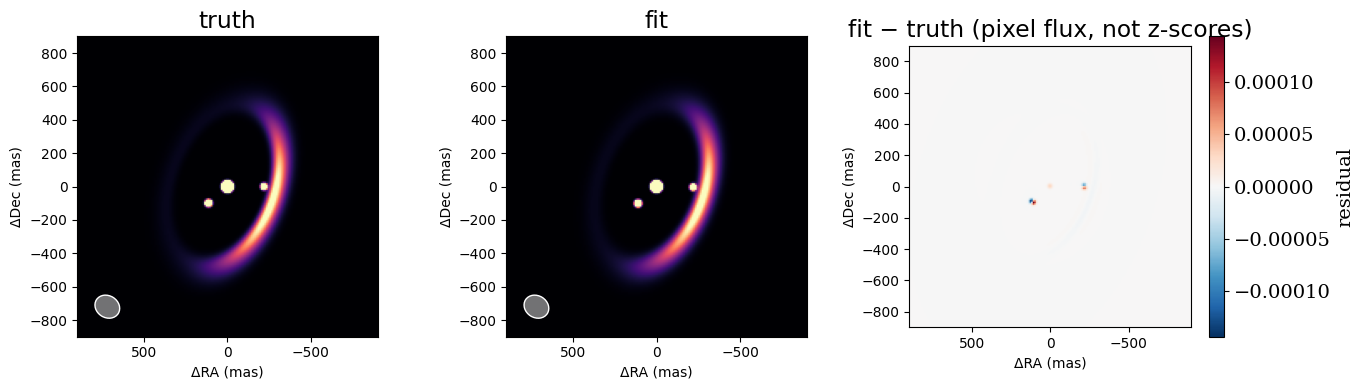

In [5]:
fov, npix = 1800.0, 180
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model, title in zip(axes, [paper, result.model], ["truth", "fit"]):
    plot_model(
        model, fov, npix, ax=ax, title=title, saturate=0.995,
        beam=beam(data),
    )
residual = result.model.render(npix, fov) - paper.render(npix, fov)
plot_residual_map(
    residual, fov, ax=axes[2],
    title="fit − truth (pixel flux, not z-scores)",
)
plt.tight_layout()
plt.show()

## Summary

`FlaredDiskPowerLaw` reproduces the PDS 70 disk model of Blakely et al. (2024) as an ordinary drpangloss component, so the star, the two planets and the disk compose into one `System` and fit with `fit` like any other model. On simulated data at the precision of an AMIGO product, all fifteen parameters come back within about two standard errors at χ²/N ≈ 1, so the model and the fitting machinery are sound before they meet the real data.